#Electric Motor Temperature Prediction using Machine Learning


Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Reading Dataset

In [2]:
df = pd.read_csv("/content/measures_v2.csv")
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17.0
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17.0
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17.0
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17.0
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17.0


#Descriptive analysis

Dataset Information

In [3]:
# Display dataset information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84155 entries, 0 to 84154
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   u_q             84155 non-null  float64
 1   coolant         84155 non-null  float64
 2   stator_winding  84155 non-null  float64
 3   u_d             84155 non-null  float64
 4   stator_tooth    84155 non-null  float64
 5   motor_speed     84155 non-null  float64
 6   i_d             84154 non-null  float64
 7   i_q             84154 non-null  float64
 8   pm              84154 non-null  float64
 9   stator_yoke     84154 non-null  float64
 10  ambient         84154 non-null  float64
 11  torque          84154 non-null  float64
 12  profile_id      84154 non-null  float64
dtypes: float64(13)
memory usage: 8.3 MB


In [4]:
df.shape

(84155, 13)

# Statistical Summary

In [5]:


df.describe()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
count,84155.000000,84155.000000,84155.000000,84155.000000,84155.000000,84155.000000,84154.000000,84154.000000,84154.000000,84154.000000,84154.000000,84154.000000,84154.000000
mean,76.628907,18.854301,55.725601,-61.208800,45.700916,2941.400545,-81.788217,69.009927,51.325391,35.009507,22.661981,57.921220,17.822706
std,35.516250,0.450445,27.573695,49.249280,18.391561,1454.307709,69.414737,60.166778,16.929209,10.892340,1.368423,51.237567,9.443704
min,-0.974433,17.123543,19.049341,-131.247696,18.268650,-0.006299,-246.089752,-0.000785,20.856956,18.076689,18.558733,-0.932627,5.000000
25%,43.710464,18.530677,36.217218,-96.629539,32.753918,1999.977051,-138.297218,1.097306,36.854153,27.229649,22.026246,0.004656,12.000000
50%,83.185867,18.826689,49.578053,-84.372490,42.043091,2569.971436,-44.263397,53.481667,48.159338,33.320284,23.166046,48.722324,17.000000
75%,97.180935,19.208430,72.121643,-5.425571,57.759943,4499.959473,-33.038481,132.617111,63.554778,41.845968,23.407086,101.848280,21.000000
max,131.628311,21.393656,131.437012,2.676198,95.034203,4999.971191,0.004419,193.912521,91.506210,64.759232,25.875355,183.115402,32.000000


In [6]:
# Check null values

df.isnull().sum()

,0
u_q,0
coolant,0
stator_winding,0
u_d,0
stator_tooth,0
motor_speed,0
i_d,1
i_q,1
pm,1
stator_yoke,1


In [7]:
# Remove missing values
df = df.dropna()

# Verify
df.isnull().sum()

,0
u_q,0
coolant,0
stator_winding,0
u_d,0
stator_tooth,0
motor_speed,0
i_d,0
i_q,0
pm,0
stator_yoke,0


In [8]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

# Distribution Plot



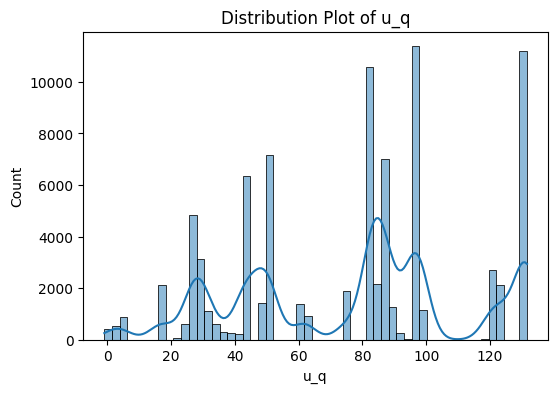

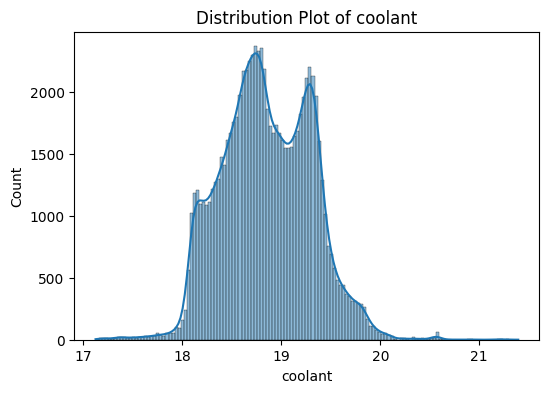

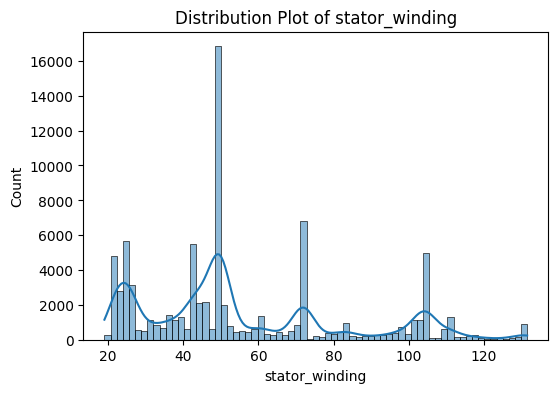

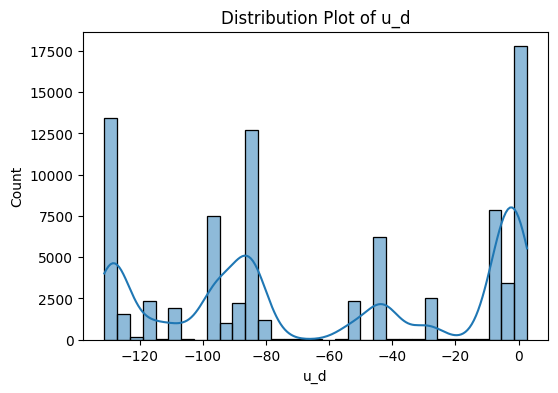

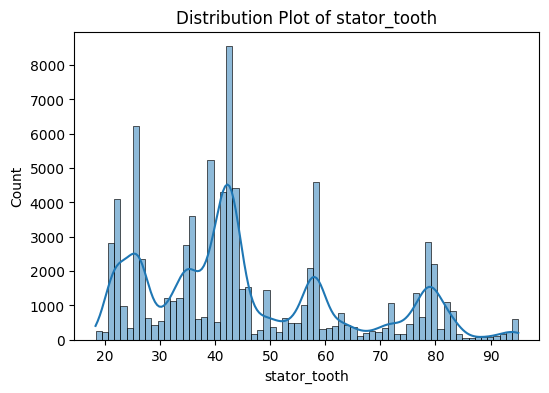

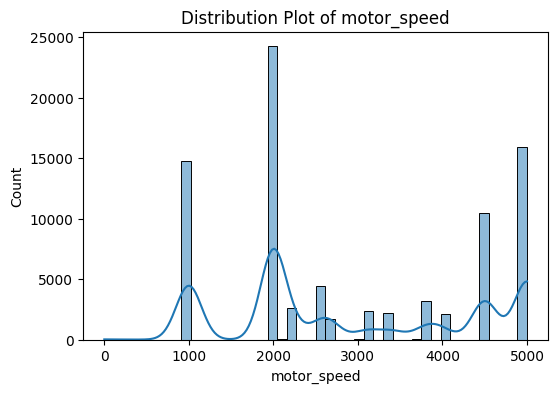

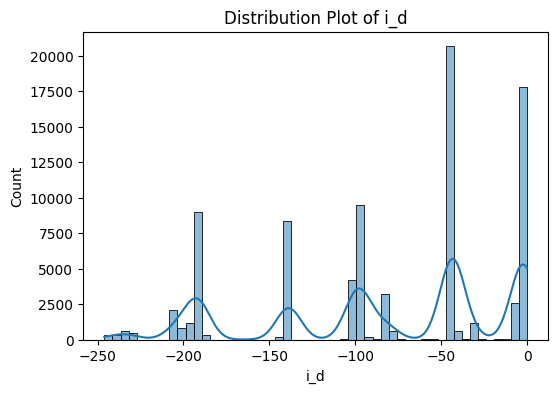

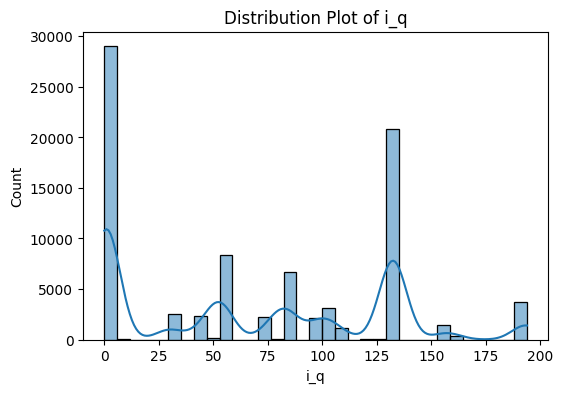

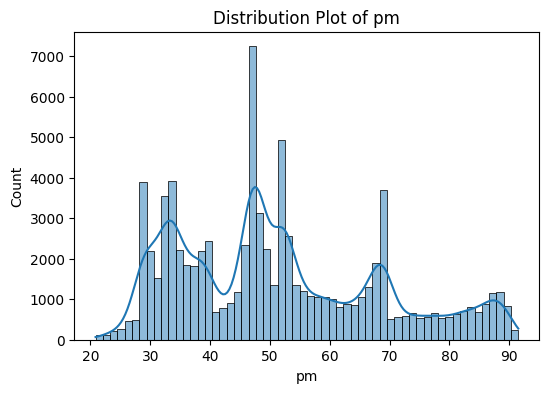

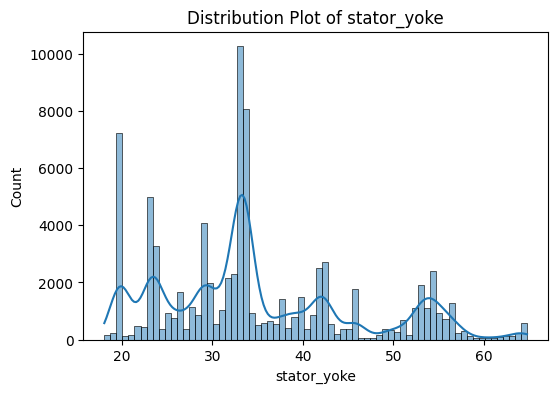

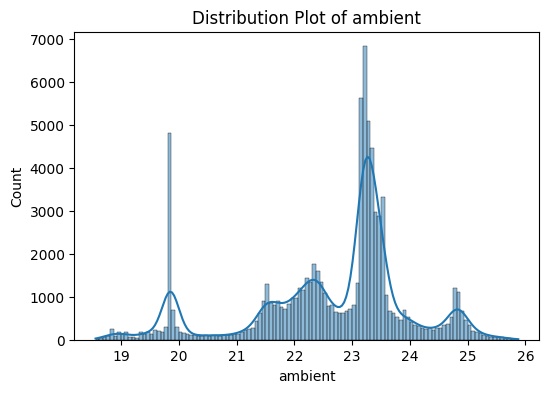

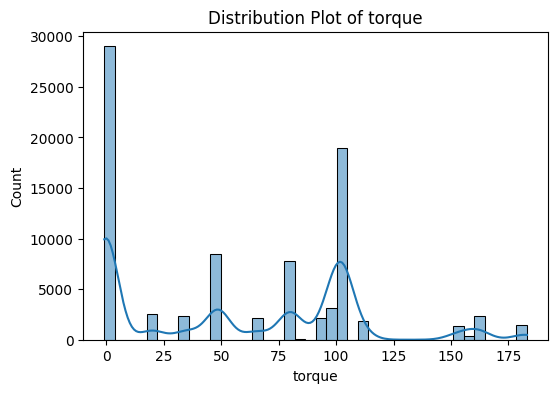

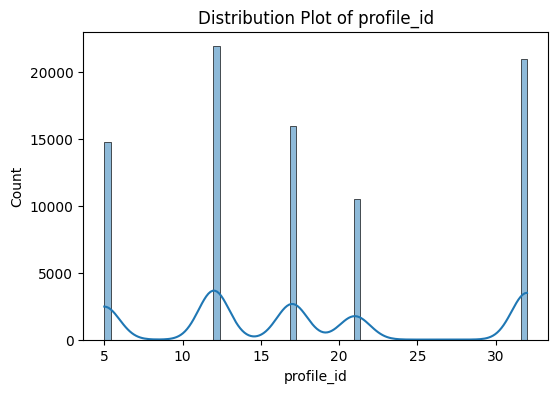

In [9]:
for column in df.columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[column], kde=True)

    plt.title(f'Distribution Plot of {column}')

    plt.show()

#Box Plot

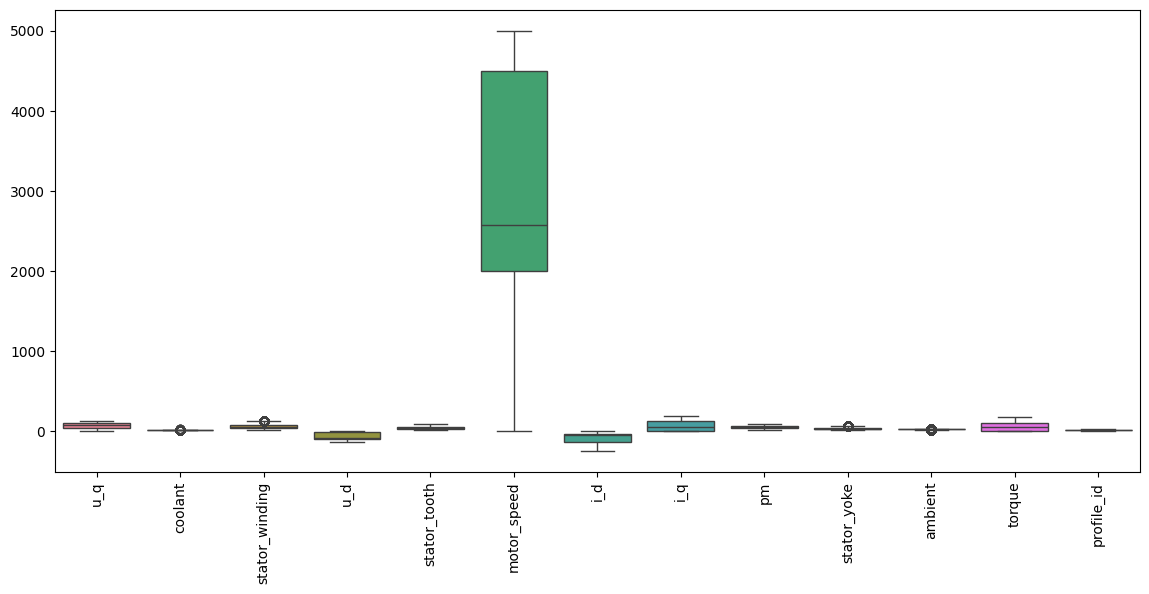

In [10]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

#Bar Plot of Profile ID

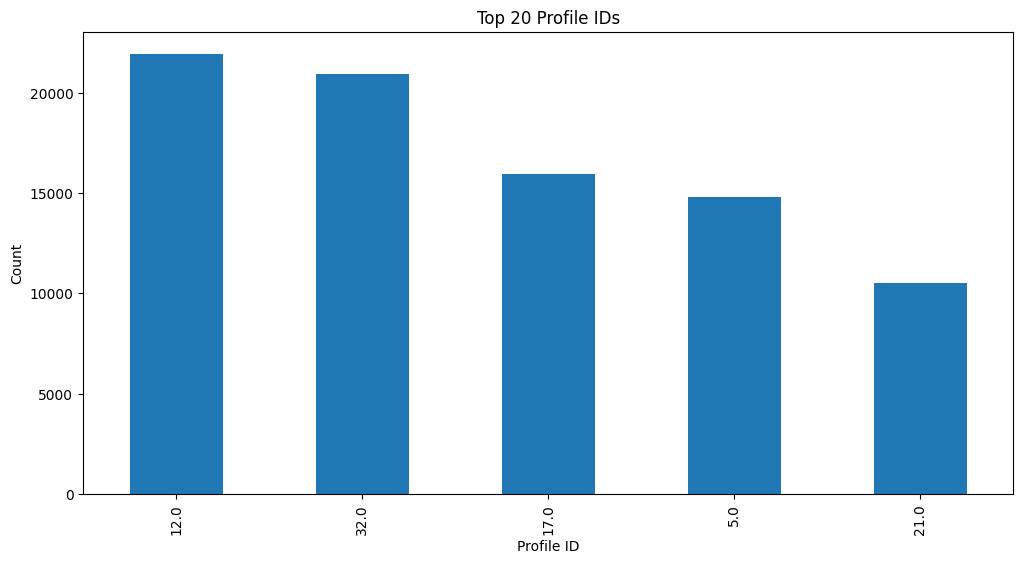

In [11]:
plt.figure(figsize=(12,6))

df['profile_id'].value_counts().head(20).plot(kind='bar')

plt.title("Top 20 Profile IDs")

plt.xlabel("Profile ID")

plt.ylabel("Count")

plt.show()

# Multivariate Analysis

#Scatter Plot

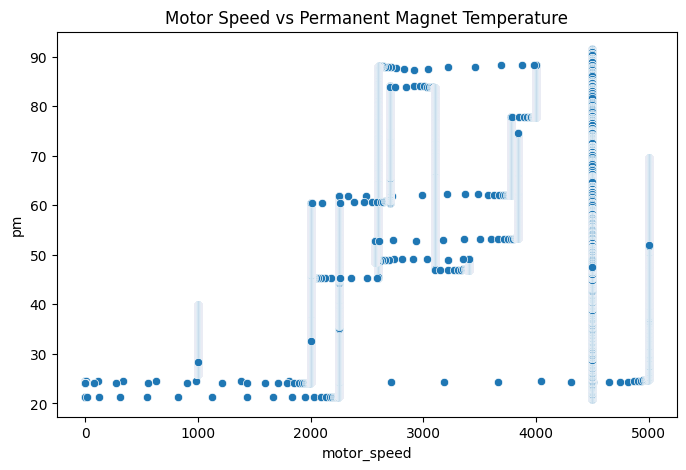

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='motor_speed',
    y='pm',
    data=df
)

plt.title("Motor Speed vs Permanent Magnet Temperature")

plt.show()

#Correlation Heatmap

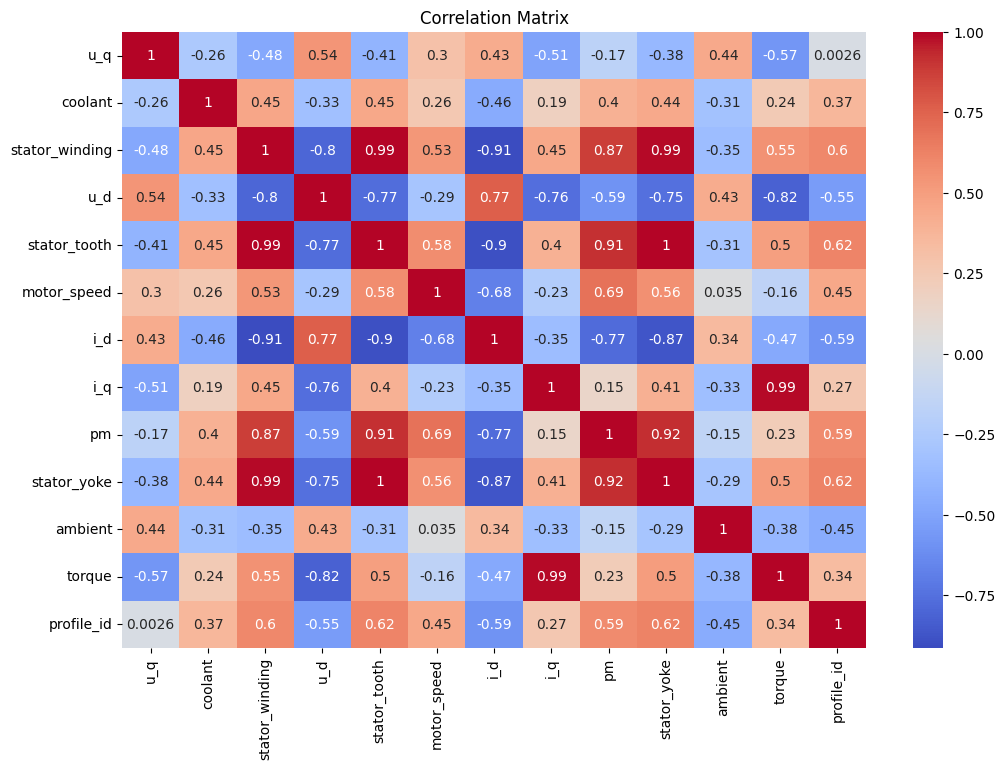

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

#Data Preprocessing

# Feature Selection & Remove Unwanted Features

In [14]:
df.columns
df = df.drop(
    [
        'stator_winding',
        'stator_tooth',
        'stator_yoke',
        'torque',
        'profile_id'
    ],
    axis=1
)

df.head()

,u_q,coolant,u_d,motor_speed,i_d,i_q,pm,ambient
0,-0.450682,18.805172,-0.350055,0.002866,0.004419,0.000328,24.554214,19.850691
1,-0.325737,18.818571,-0.305803,0.000257,0.000606,-0.000785,24.538078,19.850672
2,-0.440864,18.828770,-0.372503,0.002355,0.001290,0.000386,24.544693,19.850657
3,-0.327026,18.835567,-0.316199,0.006105,0.000026,0.002046,24.554018,19.850647
4,-0.471150,18.857033,-0.332272,0.003133,-0.064317,0.037184,24.565397,19.850639


# Independent and Dependent Variables

In [15]:
X = df.drop('pm', axis=1)

y = df['pm']

In [16]:
print(X.shape)
print(y.shape)

(84154, 7)
(84154,)


# Feature Scaling using MinMaxScaler

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[3.94977514e-03, 3.93813743e-01, 9.77403190e-01, ...,
        1.00000000e+00, 5.74202389e-06, 1.76578467e-01],
       [4.89202192e-03, 3.96951628e-01, 9.77733613e-01, ...,
        9.99984505e-01, 0.00000000e+00, 1.76575860e-01],
       [4.02381193e-03, 3.99339994e-01, 9.77235572e-01, ...,
        9.99987283e-01, 6.04301414e-06, 1.76573774e-01],
       ...,
       [9.97433216e-01, 4.55931362e-01, 9.41596212e-01, ...,
        6.57063328e-01, 5.40592584e-03, 5.85878530e-01],
       [9.97192717e-01, 4.52989120e-01, 9.41743204e-01, ...,
        6.56999867e-01, 5.39882234e-03, 5.68999825e-01],
       [9.97321597e-01, 4.35961013e-01, 9.41427263e-01, ...,
        6.57141019e-01, 5.40389100e-03, 5.56905770e-01]])

In [18]:
import pickle

pickle.dump(
    scaler,
    open('transform.pkl','wb')
)

# Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(67323, 7)
(16831, 7)
(67323,)
(16831,)


# MODEL BUILDING

In [21]:
# Import Models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR



In [22]:
# Import Algorithms

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [23]:
# Create Models

lr = LinearRegression()

dr = DecisionTreeRegressor()

rf = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

svm = SVR()

In [24]:
# Train Models

lr.fit(X_train, y_train)

dr.fit(X_train, y_train)

rf.fit(
    X_train[:100000],
    y_train[:100000]
)

svm.fit(
    X_train[:50000],
    y_train[:50000]
)

SVR()

In [25]:
# Prediction

p1 = lr.predict(X_test)

p2 = dr.predict(X_test)

p3 = rf.predict(X_test)

p4 = svm.predict(X_test[:10000])


In [26]:

# Import Metrics

from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import numpy as np
import pandas as pd

In [27]:

# Model Comparison

results = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'SVR'
    ],

    'R2 Score':[
        metrics.r2_score(y_test,p1),
        metrics.r2_score(y_test,p2),
        metrics.r2_score(y_test,p3),
        metrics.r2_score(y_test[:10000],p4)
    ],

    'MSE':[
        mean_squared_error(y_test,p1),
        mean_squared_error(y_test,p2),
        mean_squared_error(y_test,p3),
        mean_squared_error(y_test[:10000],p4)
    ],

    'RMSE':[
        np.sqrt(mean_squared_error(y_test,p1)),
        np.sqrt(mean_squared_error(y_test,p2)),
        np.sqrt(mean_squared_error(y_test,p3)),
        np.sqrt(mean_squared_error(y_test[:10000],p4))
    ],

    'MAE':[
        mean_absolute_error(y_test,p1),
        mean_absolute_error(y_test,p2),
        mean_absolute_error(y_test,p3),
        mean_absolute_error(y_test[:10000],p4)
    ]
})

results

,Model,R2 Score,MSE,RMSE,MAE
0,Linear Regression,0.672868,93.434952,9.666176,6.592407
1,Decision Tree,0.996018,1.137408,1.066493,0.294161
2,Random Forest,0.998121,0.536690,0.732591,0.237973
3,SVR,0.887566,32.178571,5.672616,3.239830


In [28]:
# Best Model

results.sort_values(
    by='R2 Score',
    ascending=False
)


,Model,R2 Score,MSE,RMSE,MAE
2,Random Forest,0.998121,0.536690,0.732591,0.237973
1,Decision Tree,0.996018,1.137408,1.066493,0.294161
3,SVR,0.887566,32.178571,5.672616,3.239830
0,Linear Regression,0.672868,93.434952,9.666176,6.592407


In [29]:
# Save Best Model

import pickle

pickle.dump(
    rf,
    open('model.pkl','wb')
)


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


In [31]:
# Save Scaler

pickle.dump(
    scaler,
    open('transform.pkl','wb')
)

In [32]:
# Test Prediction

sample = X_test[0:1]

prediction = rf.predict(sample)

print("Predicted PM Temperature :", prediction[0])

Predicted PM Temperature : 86.11317749023438


In [33]:
# Verify Files

import os

os.listdir()

['.config',
 'measures_v2.csv',
 'model.pkl',
 '.ipynb_checkpoints',
 'transform.pkl',
 'sample_data']

In [34]:
from google.colab import files

files.download('model.pkl')

files.download('transform.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>